# Low-Resource Customer Feedback Sentiment Analysis

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.config import *
from src.dataset import *
from src.model import *
from src.utils import *

In [2]:
print("Device:", DEVICE)
print("Model:", MODEL_NAME)

Device: cpu
Model: distilbert-base-uncased


In [3]:
train_df, valid_df, test_df, unlabelled_df = load_data()

print(train_df.head())

  sentiment                                               text
0  positive  Perfect fit. 2014 durango limited. Super easy ...
1  negative  Better fans out there for the price. Switch wa...
2  positive  This is easy enough to install.  There is a re...
3  positive  Great product for dual wheels. Use them on the...
4  positive  This thing is amazing. I bought one for my hus...


In [4]:
print(train_df.shape)
print(valid_df.shape)
print(test_df.shape)
print(unlabelled_df.shape)

(1000, 2)
(100, 2)
(250, 2)
(1000, 1)


In [5]:
train_df["sentiment"].value_counts()

sentiment
positive    782
negative    218
Name: count, dtype: int64

In [6]:
train_dataset, valid_dataset, test_dataset, unlabelled_dataset, tokenizer = get_datasets()

print(train_dataset[0])

{'input_ids': tensor([  101,  3819,  4906,  1012,  2297, 22959,  3995,  3132,  1012,  3565,
         3733,  2000, 16500,  1012,  2625,  2084,  2322,  8117,  1012,  4530,
         1996,  8622,  1010, 25672,  1018, 19947,  1998,  2404,  2009,  2067,
         2362,  1012,  3082,  1011,  4611,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 'labels': tensor(1)}


In [7]:
model = load_model()

print_model_summary(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model Summary
--------------------------------------------------
Model Name       : distilbert-base-uncased
Device           : cpu
Number of Labels : 2
Max Length       : 64
Trainable Params : 66,955,010


In [8]:
%run src/train.py

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


100%|██████████| 125/125 [05:28<00:00,  2.63s/it]


Training Loss : 0.4959
Validation Accuracy : 0.8300


...

Training Loss : 0.2550
Validation Accuracy : 0.8900


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\best_model
Best model saved.

Epoch 3/3


100%|██████████| 125/125 [05:27<00:00,  2.62s/it]


Training Loss : 0.1129
Validation Accuracy : 0.8800

Training completed.
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt

Evaluation Results
------------------------------
Accuracy    : 0.8900
Precision   : 0.9231
Recall      : 0.9351
F1          : 0.9290


In [9]:
%run src/evaluate.py

Loading model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:17<00:00,  1.06s/it]



Evaluation Results
------------------------------
Accuracy    : 0.8640
Precision   : 0.9038
Recall      : 0.9307
F1          : 0.9171
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt

Evaluation completed.
Metrics saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\metrics.txt
Predictions saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\predictions.csv
Confusion matrix saved to: C:\HP LAPTOP\Projects\Low-Resource-Customer-Feedback-Sentiment-Analysis\outputs\confusion_matrix.png


In [10]:
with open("outputs/metrics.txt") as file:
    print(file.read())

accuracy: 0.8640
precision: 0.9038
recall: 0.9307
f1: 0.9171



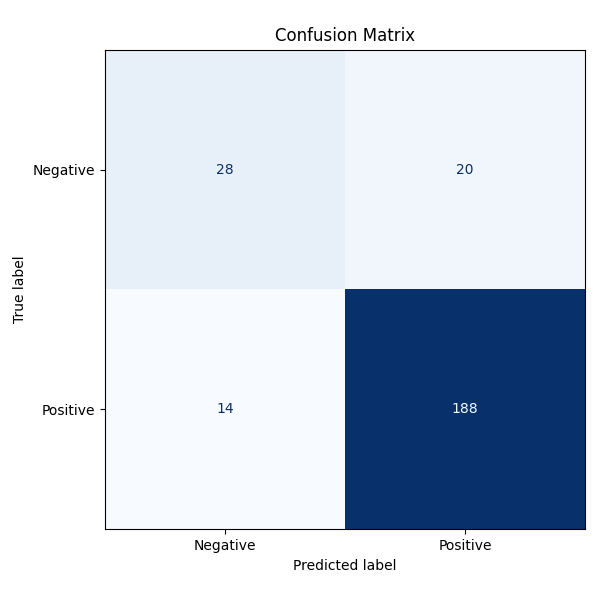

In [11]:
from PIL import Image

Image.open("outputs/confusion_matrix.png")

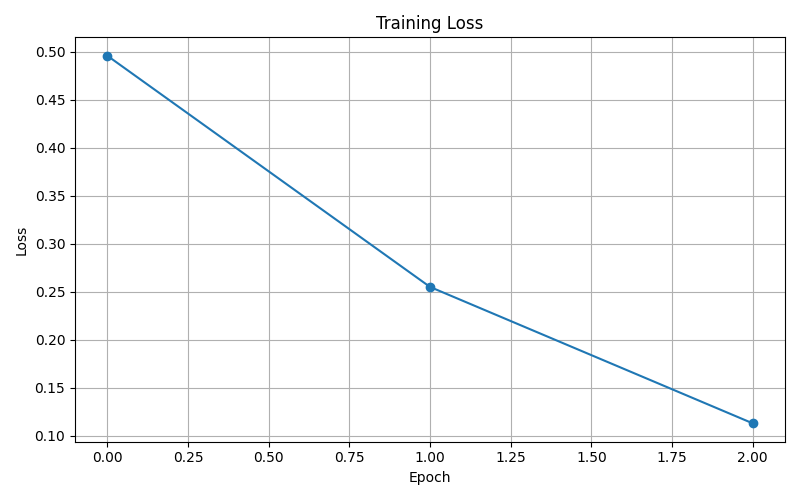

In [12]:
Image.open("outputs/training_loss.png")

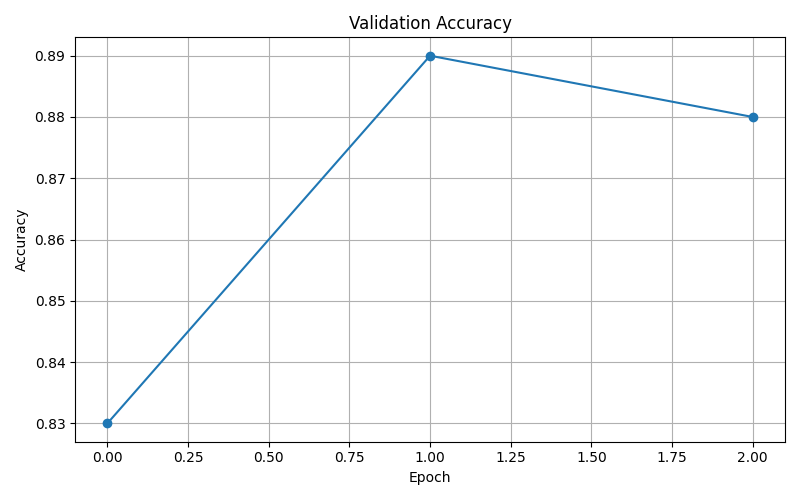

In [13]:
Image.open("outputs/validation_accuracy.png")

In [14]:
text = "The product quality is excellent."

encoding = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
)

encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

model.eval()

with torch.no_grad():
    outputs = model(**encoding)

prediction = torch.argmax(outputs.logits, dim=1).item()

print(ID2LABEL[prediction])

positive


In [15]:
text = "The delivery was terrible and customer support was disappointing."

encoding = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True,
)

encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)

prediction = torch.argmax(outputs.logits, dim=1).item()

print(ID2LABEL[prediction])

negative


In [16]:
print("Notebook execution completed successfully.")

Notebook execution completed successfully.
